# Knowledge Graphs and Semantic Technologies -- KG measures and clustering tutorial

First, make sure you have networkx installed, here you can find the [documentation](https://networkx.org/documentation/stable/reference/index.html).

In [23]:
## Uncomment if you do not have networkx installed (you should have it installed from the RDFS tutorial)
#import sys
#!{sys.executable} -m pip install networkx

import pandas as pd
import rdflib
from rdflib import Literal
from rdflib.namespace import DC, FOAF, RDF, OWL

import networkx as nx
from owlready2 import *
from owlready2 import get_ontology
from rdflib.term import URIRef, BNode
from rdflib.extras.external_graph_libs import rdflib_to_networkx_digraph

In this tutorial, we will focus on how to characterize an ontology or knowledge graph.

Load the ontology, which you have previously created in the OWL tutorial (load the asserted owl file).

In [24]:
ontology = rdflib.Graph()
ontology.parse("data/my_music_ontology_inferred.owl")

<Graph identifier=Naea97f3a8599473389a5457f76c960e1 (<class 'rdflib.graph.Graph'>)>

## 1. Basic (ontology) measures

Let's first focus on calculating basic measures:
* number of classes
* number of properties
* number of individuals
* number of triples
* number of entities (classes, individuals, etc. anything that can be places in the subject possition in a triple/axiom)

We start by counting the number of classes in the ontology. This can be done using a SPARQL query. We want to get the unique classes used in the ontology. 

PREFIX owl: <http://www.w3.org/2002/07/owl#> 
SELECT DISTINCT ?s 
WHERE { ?s rdf:type owl:Class. FILTER isURI(?s) }')

This query gives as all the classes that also have a definition in the ontology. However, this does not have to equal the number of classes actually used by individuals. Hence, you need to be very specific about what the number you are retriving represents.

In [25]:
answer = list(ontology.query(
    'PREFIX owl: <http://www.w3.org/2002/07/owl#> SELECT DISTINCT ?s WHERE { ?s rdf:type owl:Class. FILTER isURI(?s) }'
))
print("Number of classes: {f}".format(f=len(answer)))
for r in answer:
    print(r)


Number of classes: 9
(rdflib.term.URIRef('http://test.org/myonto.owl#Person'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Artist'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Location'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Song'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Genre'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#Member'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#SoloArtist'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#SubGenre'),)
(rdflib.term.URIRef('http://test.org/myonto.owl#CollaboratingArtist'),)


Even though we used a query, a lot of this information can also be retrieved with owlready2. For example, the number of classes can be retrieved with the function onto.classes(). It returns all classes in the ontology. We try it below.

In [26]:
onto_file = "data/my_music_ontology_inferred.owl"
or_ontology = get_ontology(onto_file).load()
answer = list(or_ontology.classes())

print("Number of classes: {f}".format(f=len(answer)))
for r in answer:
    print(r)

Number of classes: 9
my_music_ontology_inferred.Artist
my_music_ontology_inferred.Song
my_music_ontology_inferred.Location
my_music_ontology_inferred.Genre
my_music_ontology_inferred.Person
my_music_ontology_inferred.Member
my_music_ontology_inferred.SoloArtist
my_music_ontology_inferred.SubGenre
my_music_ontology_inferred.CollaboratingArtist


In [27]:
ind = list(or_ontology.individuals())
print(len(ind))

13


### Exercise 1

Get the following metrics from the Hybrid Intelligence ontology, using queries and check your answer using owlready2 functions.

* number of properties
* number of individuals
* number of triples
* number of entities (classes, individuals, etc. anything that can be places in the subject possition in a triple/axiom)

In [28]:
### your code here.
HI_FILE = "data/hi_ontology.ttl"

g = rdflib.Graph()
g.parse(HI_FILE, format="turtle")

# SPARQL - rdflib

# number of properties
q_properties = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
SELECT (COUNT(DISTINCT ?p) AS ?cnt)
WHERE {
  { ?p rdf:type owl:ObjectProperty . }
  UNION { ?p rdf:type owl:DatatypeProperty . }
  UNION { ?p rdf:type owl:AnnotationProperty . }
  FILTER isIRI(?p)
}
"""
num_properties = int(list(g.query(q_properties))[0][0])

# number of individuals
q_individuals = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
SELECT (COUNT(DISTINCT ?i) AS ?cnt)
WHERE {
  ?i rdf:type owl:NamedIndividual .
  FILTER isIRI(?i)
}
"""
num_individuals = int(list(g.query(q_individuals))[0][0])

# number of triples
num_triples = len(g)

# number of entities
q_entities = """
SELECT (COUNT(DISTINCT ?s) AS ?cnt)
WHERE {
  ?s ?p ?o .
  FILTER isIRI(?s)
}
"""
num_entities = int(list(g.query(q_entities))[0][0])

print("SPARQL - rdflib")
print("number of properties:", num_properties)
print("number of individuals:", num_individuals)
print("number of triples:", num_triples)
print("number of entities:", num_entities)

# owlready2
abs_path = os.path.abspath(HI_FILE)
onto = get_ontology(f"file://{abs_path}").load(format="turtle")

# properties
or_obj_props = list(onto.object_properties())
or_data_props = list(onto.data_properties())
or_anno_props = list(onto.annotation_properties())
or_num_properties = len(or_obj_props) + len(or_data_props) + len(or_anno_props)

# individuals
or_individuals = list(onto.individuals())
or_num_individuals = len(or_individuals)

# triples (reuse rdflib count)
or_num_triples = num_triples

# entities: classes + properties + individuals
or_classes = list(onto.classes())
or_num_entities_simple = len(or_classes) + or_num_properties + or_num_individuals

print("\nowlready2")
print("number of properties:", or_num_properties)
print("  - object properties:", len(or_obj_props))
print("  - data properties:", len(or_data_props))
print("  - annotation properties:", len(or_anno_props))
print("number of individuals:", or_num_individuals)
print("number of triples:", or_num_triples)
print("entities check:", or_num_entities_simple)

SPARQL - rdflib
number of properties: 13
number of individuals: 28
number of triples: 114
number of entities: 57

owlready2
number of properties: 0
  - object properties: 0
  - data properties: 0
  - annotation properties: 0
number of individuals: 0
number of triples: 114
entities check: 0


## 2. Converting KGs into Gs

To make use of graph measure, we need to convert our ontology into a mathematical graph networkx.


We first need to remove all the logics before we can do the conversion.
We are interested in keeping the following things:
* individual
* classes
* relationships between individuals and classes

What we need to remove is:
* restrictions
* domain/range
* property definitions

There is two ways for us to do it: we can either remove the information from the existing graph, or create a new graph using only the information we are interested in. Depending on the size and complexity of your knowledge graph, one way will be more preferrable than the other. You also need to consider if you want to keep the inferred information in your graph after conversion or not. Here, we want to keep the inferred information, but that is depended on the task you will then execute (for link prediction, you probably want the uninferred ontology and use the inferred information as a test set)

rdflib comes with a function that lets us convert a rdflib graph into an networkx graph.

In [29]:
from rdflib.extras.external_graph_libs import rdflib_to_networkx_digraph
nx_graph = rdflib_to_networkx_digraph(ontology)

list(nx_graph.nodes())

[rdflib.term.URIRef('http://test.org/myonto.owl#massive_attack'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#Thing'),
 rdflib.term.URIRef('http://test.org/myonto.owl#locatedIn'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#TransitiveProperty'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Song'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#Class'),
 rdflib.term.BNode('N0b39ad8d9ed84301b58273fd2b2a7992'),
 rdflib.term.BNode('N39a9d5be949643feb46e82f483feb554'),
 rdflib.term.URIRef('http://test.org/myonto.owl#tricky'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#NamedIndividual'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Scotland'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Location'),
 rdflib.term.URIRef('http://test.org/myonto.owl#hasFan'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Artist'),
 rdflib.term.URIRef('http://test.org/myonto.owl#authorOf'),
 rdflib.term.URIRef('http://test.org/myonto.owl#releaseDate'),
 rdflib.term.URIRef('ht

As we can see, there are some blank nodes which were convered into the graph that are not very useful for us at this stage. To analyse the graph as a mathematical graph, we don't want the class restrictions or property range and domain definision in our graph, as we are not doing any reasoning anymore.

Often times, it is easier to create a new graph than removeing already modeled information from the graph. Instead of continuing with the ontology, we will create a graph from the metadata provided in 'data/musicoset_metadata', but will adhere to the ontology from before (use the property and class names,etc.)

In [30]:
csv_albums =  pd.read_csv('data/musicoset_metadata/albums.csv',sep='\t')
print(csv_albums.columns)
csv_artists =  pd.read_csv('data/musicoset_metadata/artists.csv',sep='\t')
print(csv_artists.columns)
csv_songs =  pd.read_csv('data/musicoset_metadata/songs.csv',sep='\t')
print(csv_songs.columns)
csv_tracks =  pd.read_csv('data/musicoset_metadata/tracks.csv',sep='\t')
print(csv_tracks.columns)

Index(['album_id', 'name', 'billboard', 'artists', 'popularity',
       'total_tracks', 'album_type', 'image_url'],
      dtype='str')
Index(['artist_id', 'name', 'followers', 'popularity', 'artist_type',
       'main_genre', 'genres', 'image_url'],
      dtype='str')
Index(['song_id', 'song_name', 'billboard', 'artists', 'popularity',
       'explicit', 'song_type'],
      dtype='str')
Index(['song_id', 'album_id', 'track_number', 'release_date',
       'release_date_precision'],
      dtype='str')


In [31]:
# We have prepared a simplified ontology to use in this tutorial
# This ontology doesn't have any restrictions or domain/range definitions
# this is to avoid blank nodes when converting to networx
music_onto = rdflib.Graph()
music_onto.parse("data/music_onto_simple.rdf")

nx_music = rdflib_to_networkx_digraph(music_onto)
list(nx_music.nodes())

[rdflib.term.URIRef('http://test.org/myonto.owl#SubGenre'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#Class'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Artist'),
 rdflib.term.URIRef('http://test.org/myonto.owl#SoloArtist'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Song'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Member'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#Thing'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Person'),
 rdflib.term.URIRef('http://test.org/myonto.owl#followers'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#DatatypeProperty'),
 rdflib.term.URIRef('http://test.org/myonto.owl#Genre'),
 rdflib.term.URIRef('http://test.org/myonto.owl#CollaboratingArtist'),
 rdflib.term.URIRef('http://test.org/myonto.owl'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#Ontology'),
 rdflib.term.URIRef('http://test.org/myonto.owl#hasFan'),
 rdflib.term.URIRef('http://www.w3.org/2002/07/owl#ObjectProperty'),
 rdflib.term.URIRef('http:/

This ontology no longer produces any blank nodes. So we can now populate it with the metadata loaded from the CSV.

In [32]:
music_onto.parse("data/music_onto_simple.rdf")

EX = rdflib.Namespace("http://test.org/myonto.owl#")
from rdflib import OWL,RDF,RDFS,URIRef
import json
solo_artists = ["singer",'rapper','DJ',]
band = ['band','duo']
undef = ['-']

for index, artist in csv_artists.iterrows():
    art = URIRef(EX+artist["artist_id"])
    if artist["artist_type"] in solo_artists:
        music_onto.add((art,RDF.type,EX.SoloArtist))
    elif artist["artist_type"] in band:
        music_onto.add((art,RDF.type,EX.Band))
    else:
        music_onto.add((art,RDF.type,EX.Artist))
        
    music_onto.add((art,EX.name,Literal(artist["name"])))
    music_onto.add((art,EX.followers,Literal(artist["followers"])))
    genre = URIRef(EX+artist["main_genre"].replace(' ', '_'))
    music_onto.add((art,EX.hasGenre,genre))
    music_onto.add((genre,RDF.type,EX.Genre))
    
for index, song in csv_songs.iterrows():
    s = URIRef(EX+song["song_id"])
    music_onto.add((s,RDF.type,EX.Song))
    music_onto.add((s,EX.name,Literal(song['song_name'])))
    artists = eval(song['artists'])
    for key in artists.keys():
        art = URIRef(EX+key)
        music_onto.add((art,EX.authorOf,s))


Feel free to extend your ontology to include albums and track information below. You might have to extend the basic ontology as well with some additional relations.

In [33]:
### place your code here
music_onto.add((EX.Album, RDF.type, OWL.Class))
music_onto.add((EX.Track, RDF.type, OWL.Class))
music_onto.add((EX.hasTrack, RDF.type, OWL.ObjectProperty))      # album -> track
music_onto.add((EX.trackOfAlbum, RDF.type, OWL.ObjectProperty))  # track -> album
music_onto.add((EX.hasSong, RDF.type, OWL.ObjectProperty))       # track -> song


# adding albums
for _, album in csv_albums.iterrows():
    alb = URIRef(EX + str(album["album_id"]))
    music_onto.add((alb, RDF.type, EX.Album))
    
    #if album has a name column
    if "name" in csv_albums.columns:
        music_onto.add((alb, EX.name, Literal(album["name"])))


# add tracks + connect to album + song 
for _, tr in csv_tracks.iterrows():
    t = URIRef(EX + str(tr["track_number"]))
    music_onto.add((t, RDF.type, EX.Track))
    
    # link track to album (if album_id exists in tracks.csv)
    if "album_id" in csv_tracks.columns and pd.notna(tr["album_id"]):
        alb = URIRef(EX + str(tr["album_id"]))
        music_onto.add((alb, EX.hasTrack, t))
        music_onto.add((t, EX.trackOfAlbum, alb))
    
    # link track to song (if song_id exists in tracks.csv)
    if "song_id" in csv_tracks.columns and pd.notna(tr["song_id"]):
        s = URIRef(EX + str(tr["song_id"]))
        music_onto.add((t, EX.hasSong, s))

print("Extended ontology (simple). Triples now:", len(music_onto))

Extended ontology (simple). Triples now: 224358


Now we convert the ontology to a networkx graph.

In [34]:
nx_music_graph = rdflib_to_networkx_digraph(music_onto)

### Exercise 2

* Convert the Hybrid Intellgence ontology into a networkx graph. 
* Write a function that checks for blank nodes in your networkx graph, and apply it both to the graph created above (nx_graph) and to the one you have created just now.

In [35]:
### place your code here

# converting HI ontology into a networkx graph
HI_FILE = "data/hi_ontology.ttl"

hi_rdf = rdflib.Graph()
hi_rdf.parse(HI_FILE, format="turtle")  

nx_hi_graph = rdflib_to_networkx_digraph(hi_rdf)

print("HI nodes:", nx.number_of_nodes(nx_hi_graph))
print("HI edges:", nx.number_of_edges(nx_hi_graph))


# function checking blank nodes in a networkx graph
# only count actual blank nodes, not literals or other non-URIs
def report_blank_nodes(G, show=20):
    """
    returns (count, list_of_blank_nodes) and prints a short report.
    In rdflib->networkx graphs, blank nodes are rdflib.term.BNode objects.
    """
    blanks = [n for n in G.nodes() if isinstance(n, BNode)]
    print(f"blank nodes found: {len(blanks)}")
    
    if len(blanks) > 0:
        print(f"showing up to {show} blank nodes:")
        for bn in blanks[:show]:
            print("  ", bn)
        if len(blanks) > show:
            print("  ... (more not shown)")
            
    return len(blanks), blanks



print("\nblank nodes in music inferred graph (nx_graph):")
count_music, blanks_music = report_blank_nodes(nx_graph)

print("\nblank nodes in HI graph (nx_hi_graph):")
count_hi, blanks_hi = report_blank_nodes(nx_hi_graph)

HI nodes: 62
HI edges: 114

blank nodes in music inferred graph (nx_graph):
blank nodes found: 19
showing up to 20 blank nodes:
   N0b39ad8d9ed84301b58273fd2b2a7992
   N39a9d5be949643feb46e82f483feb554
   Nf95513c4a4cb4a5a9aa4823c15102867
   Nf1315a0c891e4f1898fc427a218d4bcf
   Nd9c519f17f88448daf86d0d84b08cf62
   N88d7b4a3773b45889e5f91c769af531d
   N6e5bdd4482ad47dea74350a8b50fa7d3
   Ncf813d289bb641a38b8844d5ec7f067e
   N02ceae0e26234382be72c983ef5630b5
   N58b5bc2447194601a8ba852b4a108e5a
   N36f768b7a82e4532b06e30e641834c20
   Nac22023976ec4998b2efc0f216ac1bcd
   N36b5d52057d84bb1bc7de881016d12a6
   Ne57d3752cf43440e9c0b8f4f11e8608b
   N40931a9eb0d644afa8f73d56148ec427
   N4249176740594de088feb290b7d52c77
   N8d1c9a3065fa4aecb74723c57306a94c
   N98c13789c32d4a4493ec3edbe01729c5
   N7b18b5455c0e45fe9f78aa44265bec59

blank nodes in HI graph (nx_hi_graph):
blank nodes found: 0


## 3. Graph Measures

Now we can calculate some graph measures over the networkX graph. The library provides a lot of different measures that can be calculated. Always check what kind of assumptions the measure has:
* directed or undirected graph?
* does the graph have to be connected?

We will first calculate some basic graph measures: number of nodes, number of edges and the density of the graph.

In [36]:
print("Number of Nodes: {n}".format(n=nx.number_of_nodes(nx_music_graph)))
print("Number of Edges: {n}".format(n=nx.number_of_edges(nx_music_graph)))
print("Density of Graph: {n}".format(n=nx.density(nx_music_graph)))

Number of Nodes: 126871
Number of Edges: 224358
Density of Graph: 1.3938635363761247e-05


We will now look at the distribution of degree of our nodes by calculating (retrieving) the degree for each node and plotting a histogram. We do this with the original ontology, to show how it works. The graph which we just created is not dense enough to show much in a histogram. 

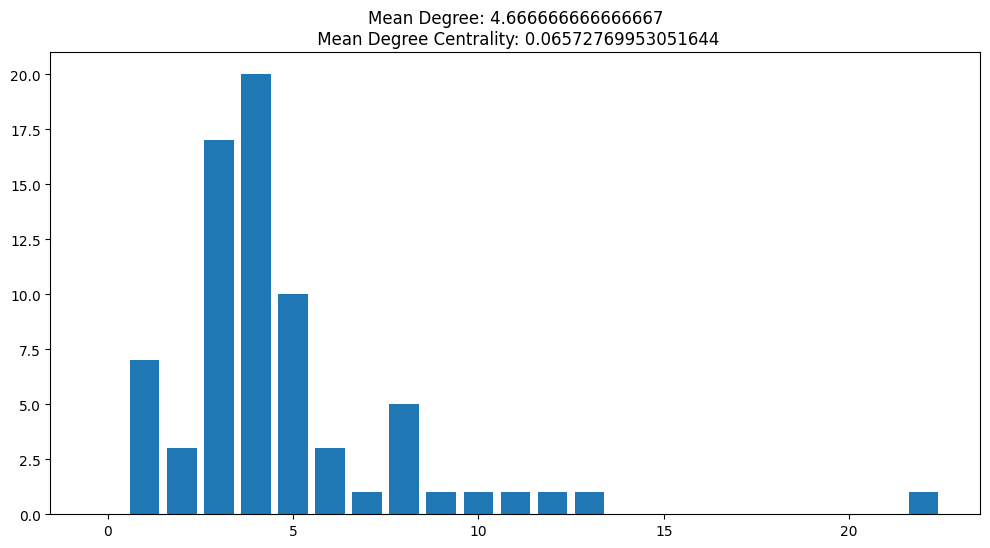

In [37]:
import matplotlib.pyplot as plt
import numpy as np


histdegree = pd.DataFrame(nx.degree_histogram(nx_graph))
degree = dict(nx.degree(nx_graph))


mean_degree = np.mean(list(degree.values()))
mean_degree_centrality = np.mean(list(nx.degree_centrality(nx_graph).values()))

fig, ax = plt.subplots(figsize=(12,6)) 
ax.bar(histdegree.index.values,histdegree[0])

plt.title("Mean Degree: {n1}\n Mean Degree Centrality: {n2}".format(n1=mean_degree,n2=mean_degree_centrality))
plt.show()

Another very useful measure is the clustering coefficient, which tells us how likely the nodes are to build clusters. This is a global measure, but can also be calculated for each node.

In [38]:
print("Clustering coefficient: {n}".format(n=nx.average_clustering(nx_graph)))

Clustering coefficient: 0.07673306631639965


### Exercise 3

Calculate and visualise the centrality of the music graph. Use a different measure than degree. For different measures you can refer to this online [documentation]{https://networkx.org/documentation/stable/reference/algorithms/centrality.html}. Choose wisely though, some measures require a long time to calculate (like betweenness or eigenvector centrality).

As a second step, take some time to explore the documentation of networkx. Is there something other you can calculate and learn about the graph?

top 10 nodes by pagerank:
http://www.w3.org/2002/07/owl#Class -> 0.067193
http://test.org/myonto.owl#Song -> 0.051086
http://test.org/myonto.owl#Album -> 0.04556
http://www.w3.org/2002/07/owl#Thing -> 0.028622
http://test.org/myonto.owl#1 -> 0.011029
http://test.org/myonto.owl#Genre -> 0.011016
http://test.org/myonto.owl#2 -> 0.005582
http://test.org/myonto.owl#3 -> 0.004258
http://test.org/myonto.owl#Artist -> 0.004103
http://test.org/myonto.owl#4 -> 0.003286


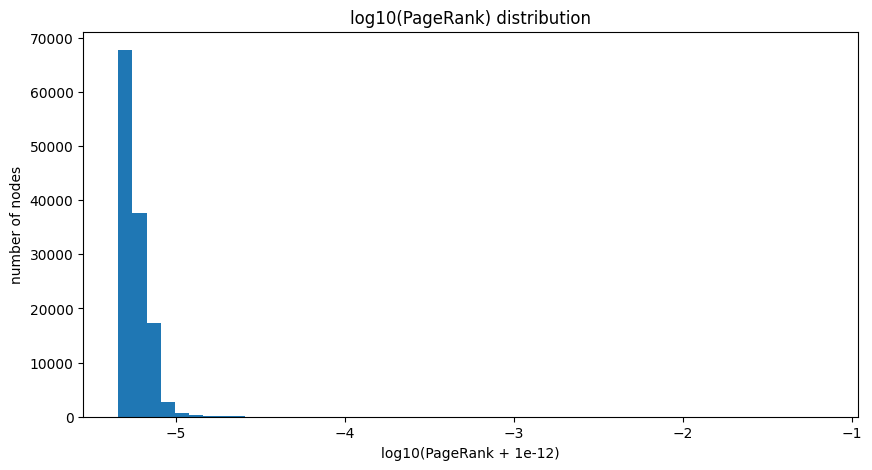


weakly connected components: 4
largest component size: 126855
top 5 component sizes: [126855, 10, 4, 2]


In [39]:
### your code here

## 1
# centrality -> pagerank (works well for directed graphs and is not too slow)
pr = nx.pagerank(nx_music_graph, alpha=0.85)

# show top 10 nodes by pagerank
top10 = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
print("top 10 nodes by pagerank:")
for n, score in top10:
    print(n, "->", round(score, 6))

# plot histogram of pagerank values
pr_values = np.array(list(pr.values()))

pr_log = np.log10(pr_values + 1e-12)  
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(pr_log, bins=50)
ax.set_title("log10(PageRank) distribution")
ax.set_xlabel("log10(PageRank + 1e-12)")
ax.set_ylabel("number of nodes")
plt.show()


## 2
wcc = list(nx.weakly_connected_components(nx_music_graph))
sizes = sorted([len(c) for c in wcc], reverse=True)

print("\nweakly connected components:", len(wcc))
print("largest component size:", sizes[0])
print("top 5 component sizes:", sizes[:5])

## 4. Visualizing your graph

With networkX you can easily visualize your ontology/graph, no matter if they include blank nodes or not. The visualisations are powered by matplotlib. We will use here the first ontology, which also has blank nodes, but is much simpler to visualize.

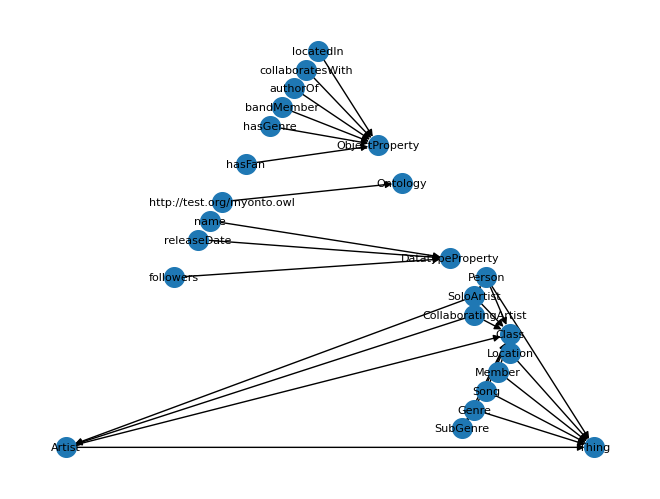

In [40]:
# list(nx_graph.nodes())

music_ontology = rdflib.Graph()
music_ontology.parse("data/music_onto_simple.rdf")
nx_graph = rdflib_to_networkx_digraph(music_ontology)


mapping = pd.DataFrame(nx_graph.nodes())
mapping['new_names'] = mapping[0].str.split("#",n=1,expand=False)
mapping['label'] = 'NA'
# print(mapping)
mapping_copy = mapping.copy()

for ind, m in mapping_copy.iterrows():
    l = len(m['new_names'])
    names = m['new_names']
    mapping.loc[ind,'label'] = names[l-1]
    
map_dict = dict(zip(mapping[0],mapping['label']))

# print(mapping)
nx_graph_nl = nx.relabel_nodes(nx_graph,map_dict,copy=True)


nx.draw_planar(nx_graph_nl,
                 with_labels=True,
                node_size=200, font_size=8 )
# plt.draw()

### Exercise 4

Try to visualize the Hybrid Intelligence ontology below. Don't shy away from looking for and trying other approaches to visualize an ontology, giving nodes different colors, or varying thickness/color of the edges based on the type of relation.

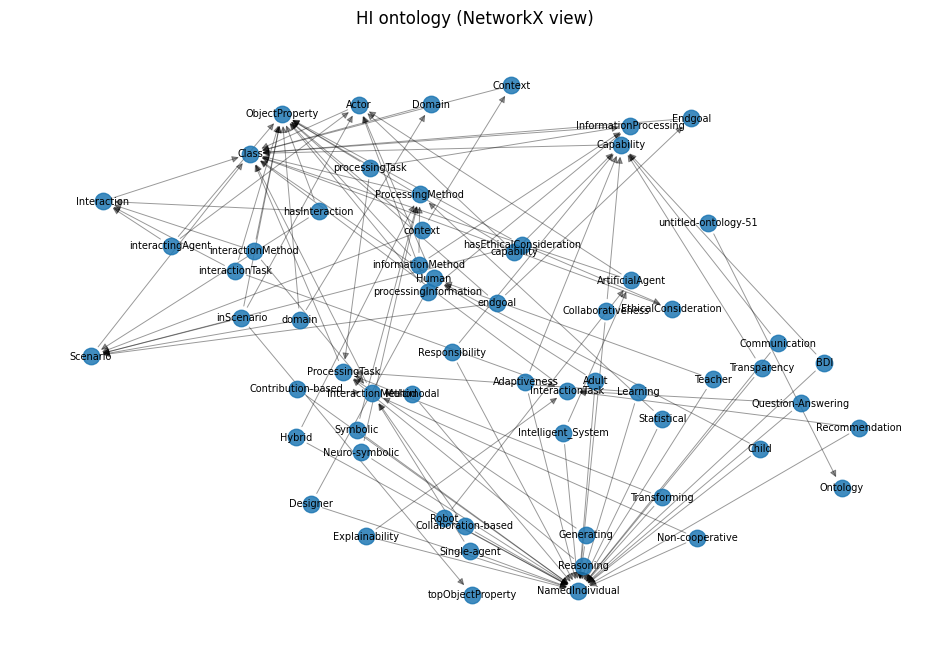

In [41]:
### your code goes here

def short_label(n):
    """make node labels readable (URI -> last fragment, BNode/Literal -> string)."""
    if isinstance(n, URIRef):
        s = str(n)
        if "#" in s:
            return s.split("#")[-1]
        return s.rsplit("/", 1)[-1]
    return str(n)

labels = {n: short_label(n) for n in nx_hi_graph.nodes()}

# categorizing nodes for coloring 
uri_nodes = [n for n in nx_hi_graph.nodes() if isinstance(n, URIRef)]
bnode_nodes = [n for n in nx_hi_graph.nodes() if isinstance(n, BNode)]
lit_nodes = [n for n in nx_hi_graph.nodes() if isinstance(n, Literal)]

pos = nx.spring_layout(nx_hi_graph, seed=7, k=0.7)

plt.figure(figsize=(12, 8))

# edges 
nx.draw_networkx_edges(nx_hi_graph, pos, alpha=0.4, width=0.7)

# nodes by type
nx.draw_networkx_nodes(nx_hi_graph, pos, nodelist=uri_nodes, node_size=140, alpha=0.85)
if len(bnode_nodes) > 0:
    nx.draw_networkx_nodes(nx_hi_graph, pos, nodelist=bnode_nodes, node_size=140, alpha=0.85)
if len(lit_nodes) > 0:
    nx.draw_networkx_nodes(nx_hi_graph, pos, nodelist=lit_nodes, node_size=90, alpha=0.75)

# labels
nx.draw_networkx_labels(nx_hi_graph, pos, labels=labels, font_size=7)

plt.title("HI ontology (NetworkX view)")
plt.axis("off")
plt.show()


## 5. Clustering

NetworkX already comes with some clustering algorithms. We will try the one introduced in the theory part of the class, Louvain clustering algorithm.

In [42]:
import networkx.algorithms.community as nx_comm


communities = nx_comm.louvain_communities(nx_graph,resolution=1)
print(1,len(communities),nx.number_of_nodes(nx_graph))


1 5 24


Now we can visualize the graph and the communities within it. Alternatively you can also visualize a community as an example alone. (WARNING: this might take a while...)

/Users/bara/opt/anaconda3/envs/knowgraphs/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


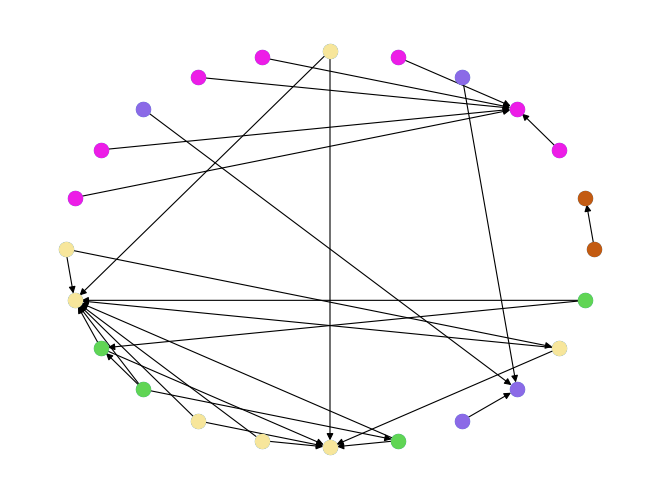

In [43]:
pos = nx.shell_layout(nx_graph)


nx.draw(nx_graph, pos, edge_color='k',font_weight='light', 
        node_size= 100, width= 0.8)
for com in communities:
    nx.draw_networkx_nodes(nx_graph,
                           pos,
                           nodelist=com, 
                           node_color=np.random.rand(3,),
                           node_size=100)
plt.show()

If clustering is successful and helpful is very dependent on your graph. It is beneficial to remove the information from your graph that is not helpful for the clustering, like the T-box of your ontology, as this "polutes" the graph. The clustering algorithm is not made for knowledge graphs but rather for mathematical graphs, hence less semantics is better.

In the case above, the graph is not dense enough to produce meaningful clusters, which is why there are 38706 clusters. 

### Exercise 5

Try to cluster your own graph. You might have to create a mathematical graph first, rather than just converting your knowledge graph, as that will lead to better and more insightful results.

clustering graph nodes: 62
clustering graph edges: 114

number of communities: 8
top 5 community sizes: [19, 14, 10, 5, 5]


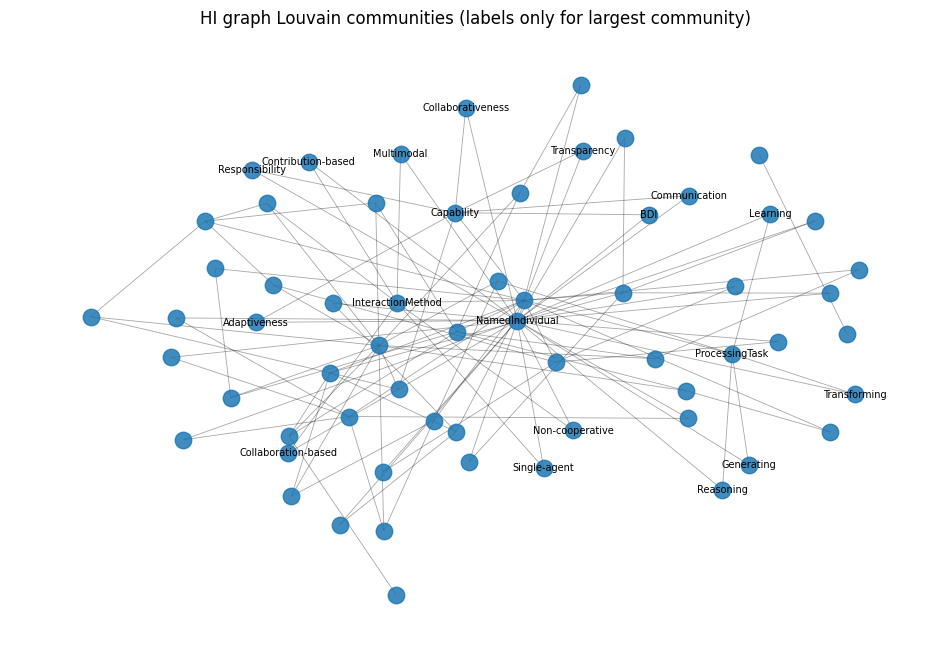

In [44]:
### your code goes here.

# removing literals, keep URIs + blank nodes
nodes_keep = [n for n in nx_hi_graph.nodes() if not isinstance(n, Literal)]
Gc = nx_hi_graph.subgraph(nodes_keep).copy()

print("clustering graph nodes:", Gc.number_of_nodes())
print("clustering graph edges:", Gc.number_of_edges())

# Louvain wants an undirected graph
Gu = Gc.to_undirected()

communities = nx_comm.louvain_communities(Gu, resolution=1.0, seed=7)
sizes = sorted([len(c) for c in communities], reverse=True)

print("\nnumber of communities:", len(communities))
print("top 5 community sizes:", sizes[:5])

# visualization
pos = nx.spring_layout(Gu, seed=7, k=0.7)

plt.figure(figsize=(12, 8))
nx.draw_networkx_edges(Gu, pos, alpha=0.35, width=0.6)

for i, com in enumerate(communities):
    nx.draw_networkx_nodes(
        Gu, pos,
        nodelist=list(com),
        node_size=140,
        alpha=0.85
    )

def short_label(n):
    if isinstance(n, URIRef):
        s = str(n)
        if "#" in s:
            return s.split("#")[-1]
        return s.rsplit("/", 1)[-1]
    return str(n)

largest_com = max(communities, key=len)
labels = {n: short_label(n) for n in largest_com}

nx.draw_networkx_labels(Gu, pos, labels=labels, font_size=7)

plt.title("HI graph Louvain communities (labels only for largest community)")
plt.axis("off")
plt.show()